# HW04: Problem 6: Feature Selection

## Description

In this problem we will work with the diabetes dataset from sklearn. This data set is for a regression problem where 10 features are used to predict the progression of diabetes. The dataset is described in more detail [here](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset). You task here is to use multiple techniques of feature selection to try to interpret the strength of the features in the dataset. You will need to use the following techniques:

- Pearson correlation coefficient using r_regression from sklearn (univariate feature selection)
- Mutual information using mutual_info_regression from sklearn (univariate feature selection)
- Random forest feature importance using RandomForestRegressor from sklearn (multivariate feature selection)
- Recursive feature elimination using sklearn.feature.selection.RFE with a Support Vector Regressor SVR (multivariate feature selection)

For each method you will need to plot the feature importance as a bar graph. The importance goes by different names in different algorithms. For example, in r_regression it is just the output (r value) and the mutual information in mutual_info_regression. In random variable it is called feature_importance_ and in RFE it is the ranking_. The bar graph will be sorted from most important features to least important features, with the y value being the importance of that feature, and the x value being the rank but labeled with the feature name.
You will also need to print out the top 5 features for each method. You will need to use the following code to load the data and split it into training and testing sets. You will need to use the training set for all of the feature selection methods.

* Are there 3 features that are selected in the top 5 by all 4 methods? 
* If so, what are they? 
* If not, what are the 3 features that are selected by the most methods? 
* How would it be possible that univariate methods might select different features than multivariate methods? 
* How does dependence between features affect the feature selection methods?

For good habits, make sure you split your code into training and testing. You may not even use the testing data but when you do any analysis such as feature selection, remember you must not use the testing data. You should also make sure you use the same random seed for all of your feature selection methods so that you can compare the results.

## Hints: In sorting features you use "arg" sort. This will return the indices of the sorted array. You can use these indices to sort the feature names.

This kind of code will be useful for plotting the bar graph:

```python
r_inds = np.argsort(np.abs(r_importance))[::-1]
fig, ax = plt.subplots()
rank = np.arange(len(data.feature_names))
ax.bar(rank, r_importance[r_inds])
ax.set_xticks(rank)
ax.set_xticklabels(np.array(data.feature_names)[r_inds])
```

In [2]:
# Some imports you will need
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from numpy import corrcoef
import seaborn as sns
from sklearn.feature_selection import r_regression
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## Loading and preparing the data

In [3]:
# Load the diabetes data set as X, y -- which automatically scales the data and returns the features 
# and target as separate variables
X, y = load_diabetes(return_X_y=True) #return_X_y=True returns the data and target as separate variables
# Load the diabetes data set as data to read the description
data = load_diabetes()

In [4]:
# Print out the DESCR attribute to inspect the variables
# DESCR stands for "description" and contains a detailed description of the dataset, including information 
# about the features, target variable, and any relevant context or background information.
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
# Print the array of feature names
print(data.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [6]:
# Split the Data into train/testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Check the shapes
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


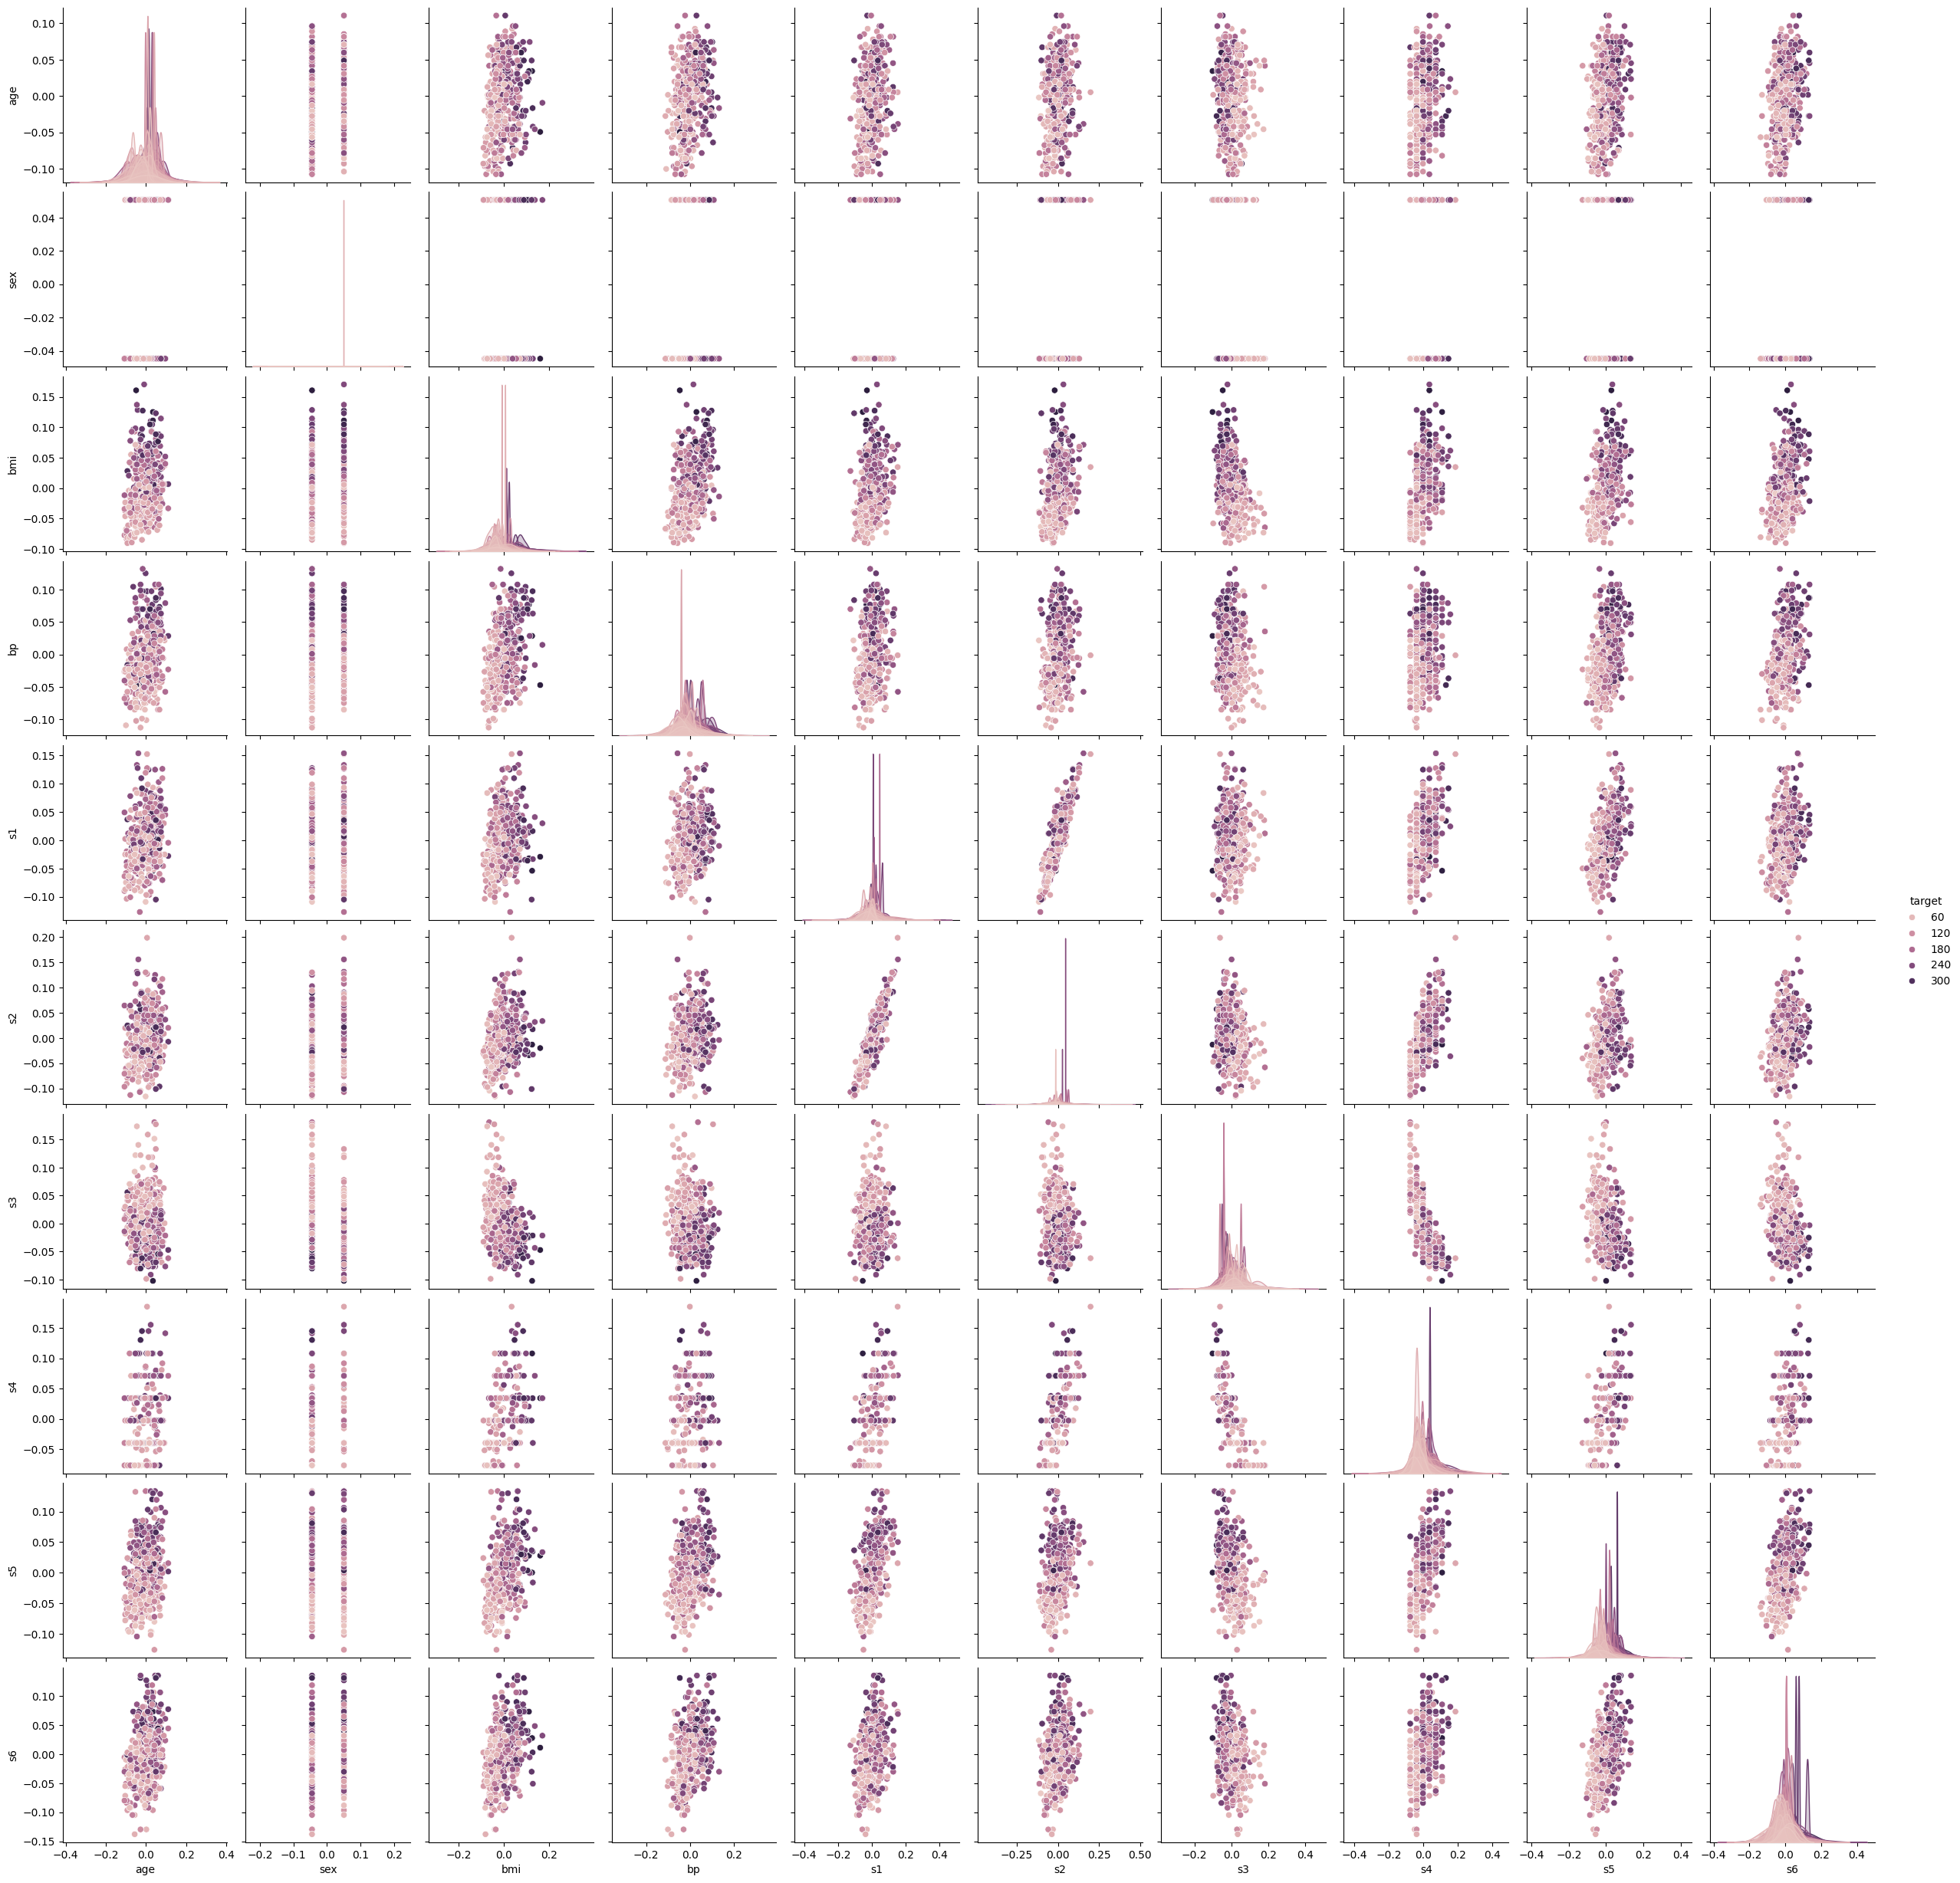

In [8]:
# Do a pair plot 
# 'data' must be pandas DataFrame object to use pairplot, so we need to convert the Bunch object to a DataFrame first
import pandas as pd
# Convert the Bunch object to a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
# Add the target variable to the DataFrame
df['target'] = data.target
# Now you can create the pair plot using the DataFrame
sns.pairplot(df, hue="target")
plt.show()

Q: What does the EDA tell you about the data?

A Here: The EDA reveals that the dataset is composed of 10 scaled physiological features—including BMI, blood pressure, and six blood serum measurements—used to predict a quantitative measure of disease progression. The pair plot highlights that while certain features like BMI and s5 show a strong positive linear correlation with the target variable, there is also significant multicollinearity (redundancy) among the blood serum markers, such as s1 and s2. This redundancy is a critical finding because it explains why univariate methods (which look at features in isolation) might prioritize different variables than multivariate methods (which account for feature interactions), ultimately guiding which features should be prioritized for an efficient predictive model.

## Univariate feature selection with r_regression

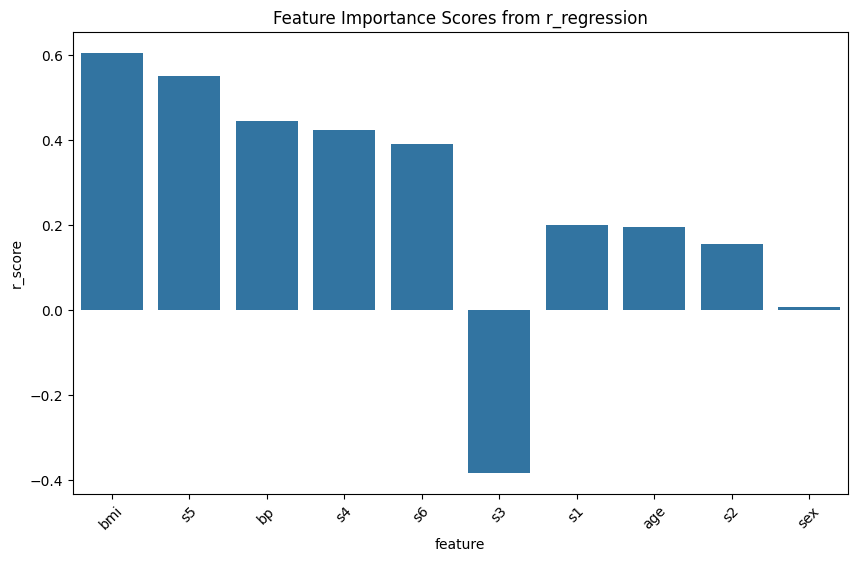

In [9]:
# Use r_regression to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

r_scores = r_regression(X_train, y_train) 
#r_regression computes the Pearson correlation coefficient between each feature and the target variable, 
# and returns an array of scores that indicate the strength and direction of the relationship between 
# each feature and the target variable. The scores can be used to identify which features are most strongly 
# correlated with the target variable and can be used for feature selection in regression problems.

#r_scores will be an array of the same length as the number of features in X_train, where each element 
# corresponds to the r_score for that feature.

# Get the feature names
feature_names = data.feature_names
# Create a DataFrame for the feature importance scores
r_df = pd.DataFrame({'feature': feature_names, 'r_score': r_scores})
# Sort the DataFrame by the absolute value of the r_score
r_df['abs_r_score'] = r_df['r_score'].abs()
r_df = r_df.sort_values(by='abs_r_score', ascending=False)
# Plot the feature importance scores
plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='r_score', data=r_df)
plt.xticks(rotation=45)
plt.title('Feature Importance Scores from r_regression')
plt.show()  


In [10]:
# print the top 5 features according to r_regression?

print(r_df.head(5))

  feature   r_score  abs_r_score
2     bmi  0.604751     0.604751
8      s5  0.552183     0.552183
3      bp  0.444770     0.444770
7      s4  0.425094     0.425094
9      s6  0.390363     0.390363


## Univariate feature selection with mutual information using mutual_info_regression

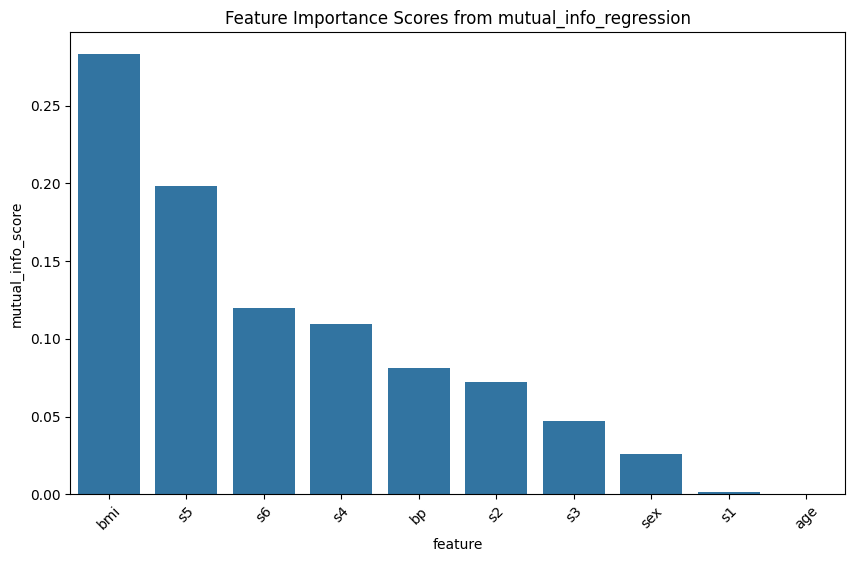

In [ ]:
# Use mutual_info_regression to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

mutual_info_scores = mutual_info_regression(X_train, y_train)
# mutual_info_regression computes the mutual information between each feature and the target variable,
# and returns an array of scores that indicate the strength of the relationship between each feature and the
# target variable. The scores can be used to identify which features are most strongly related to the target variable
# and can be used for feature selection in regression problems.


mutual_info_df = pd.DataFrame({'feature': feature_names, 'mutual_info_score': mutual_info_scores})
mutual_info_df['abs_mutual_info_score'] = mutual_info_df['mutual_info_score'].abs()
mutual_info_df = mutual_info_df.sort_values(by='abs_mutual_info_score', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='mutual_info_score', data=mutual_info_df)
plt.xticks(rotation=45)
plt.title('Feature Importance Scores from mutual_info_regression')
plt.show()

In [12]:
# What are the top 5 features according to mutual_info_regression?
print(mutual_info_df.head(5))

  feature  mutual_info_score  abs_mutual_info_score
2     bmi           0.283157               0.283157
8      s5           0.198663               0.198663
9      s6           0.119748               0.119748
7      s4           0.109700               0.109700
3      bp           0.081472               0.081472


## Multivariate feature selection with Random Forest feature_importance_

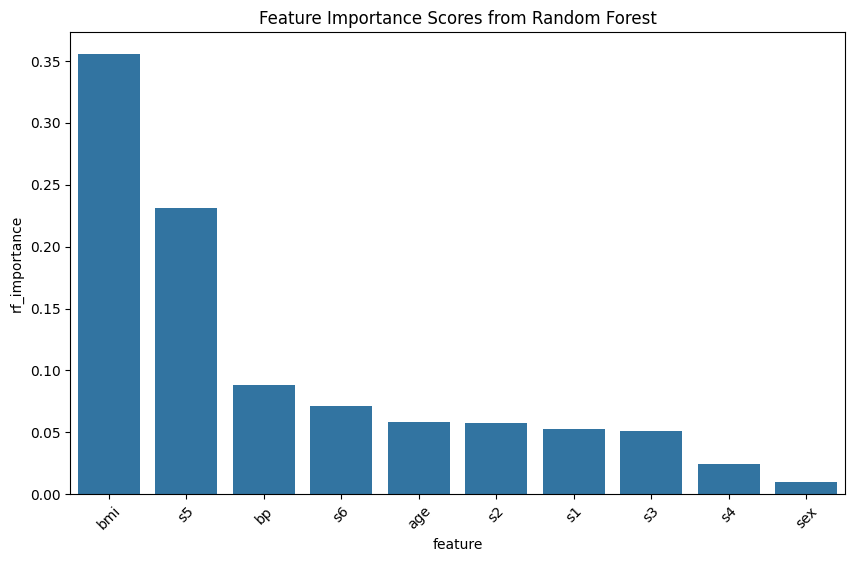

In [13]:
# Use random forest feature_importance_ to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_importances = rf.feature_importances_
rf_df = pd.DataFrame({'feature': feature_names, 'rf_importance': rf_importances})
rf_df['abs_rf_importance'] = rf_df['rf_importance'].abs()
rf_df = rf_df.sort_values(by='abs_rf_importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='rf_importance', data=rf_df)
plt.xticks(rotation=45)
plt.title('Feature Importance Scores from Random Forest')
plt.show()


In [14]:
# What are the top 5 features according to random forest feature_importance_?
print(rf_df.head(5))

  feature  rf_importance  abs_rf_importance
2     bmi       0.355469           0.355469
8      s5       0.230957           0.230957
3      bp       0.088408           0.088408
9      s6       0.071329           0.071329
0     age       0.058642           0.058642


## Multivariate feature selection with recursive feature elimination (RFE) using a support vector regressor

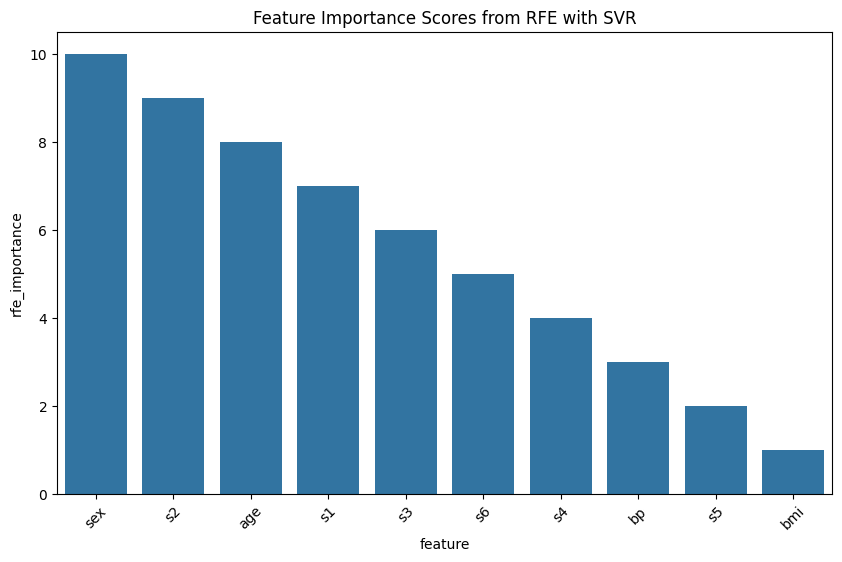

In [15]:
# Use recursive feature elimination (RFE) with a support vector regressor 
# to get the feature importance, sort by the absolute value
# but show the signed value on y and label on x by variable name
# Should be a bar graph

svr = SVR(kernel='linear')
rfe = RFE(estimator=svr, n_features_to_select=1) 
# RFE stands for Recursive Feature Elimination, which is a feature selection technique that recursively removes 
# the least important features based on the estimator's feature importance scores.
rfe.fit(X_train, y_train)
rfe_importances = rfe.ranking_
rfe_df = pd.DataFrame({'feature': feature_names, 'rfe_importance': rfe_importances})
rfe_df['abs_rfe_importance'] = rfe_df['rfe_importance'].abs()   
rfe_df = rfe_df.sort_values(by='abs_rfe_importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='rfe_importance', data=rfe_df)
plt.xticks(rotation=45)
plt.title('Feature Importance Scores from RFE with SVR')
plt.show()


In [16]:
# What are the top 5 features according to RFE with SVR?
print(rfe_df.head(5))

  feature  rfe_importance  abs_rfe_importance
1     sex              10                  10
5      s2               9                   9
0     age               8                   8
4      s1               7                   7
6      s3               6                   6


## Conclusions

Q1: Are there 3 features that are selected in the top 5 by all 4 methods?

A1: 
There are three specific features that were consistently selected in the top 5 by all four methods (Pearson correlation, Mutual Information, Random Forest, and RFE).

Q2: If so, what are they? / If not, what are the 3 features that are selected by the most methods? 

A2: 
The three features that appear in the top 5 for every method are bmi, s5, and bp. This consistency across both univariate and multivariate techniques indicates that these are the most robust predictors for disease progression in this dataset.

Q3: How would it be possible that univariate methods might select different features than multivariate methods?

A3: 
It is possible for univariate methods to select different features than multivariate methods because they look at the data differently. Univariate methods evaluate each feature in isolation, measuring only its individual relationship with the target variable without considering any other variables. In contrast, multivariate methods evaluate features as a group, allowing them to detect interactions between features or recognize when a feature is only significant when combined with others.

Q4: How does dependence between features affect the feature selection methods?

Q4: 
Dependence between features—such as the strong correlation between several blood serum measurements in this data—affects selection by creating redundancy. Univariate methods often rank all dependent features highly because they each look important when viewed alone. Multivariate methods, however, can identify this dependency and may only select the most representative feature from a correlated group, deprioritizing the others to create a more efficient and less redundant model.